<a href="https://colab.research.google.com/github/darshitp091/Aether/blob/main/Image_as_a_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import urllib.request

url = "https://images.unsplash.com/photo-1541701494587-cb58502866ab?w=500"
image_path = "sample_image.jpg"
urllib.request.urlretrieve(url, image_path)
print("Image downloaded successfully")

Image downloaded successfully


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("sample_image.jpg")

if img.max() > 1.0:
    img = img / 255.0

gray_img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])

In [3]:
bright_img = np.clip(gray_img + 0.3, 0.0, 1.0)
dark_img = np.clip(gray_img - 0.3, 0.0, 1.0)

flip_lr = np.fliplr(gray_img)
flip_ud = np.flipud(gray_img)

h, w = gray_img.shape
crop_img = gray_img[h//4:3*h//4, w//4:3*w//4]

In [4]:
blur_img = np.copy(gray_img)
for i in range(1, h-1):
    for j in range(1, w-1):
        neighbor_matrix = gray_img[i-1:i+2, j-1:j+2]
        blur_img[i, j] = np.mean(neighbor_matrix)

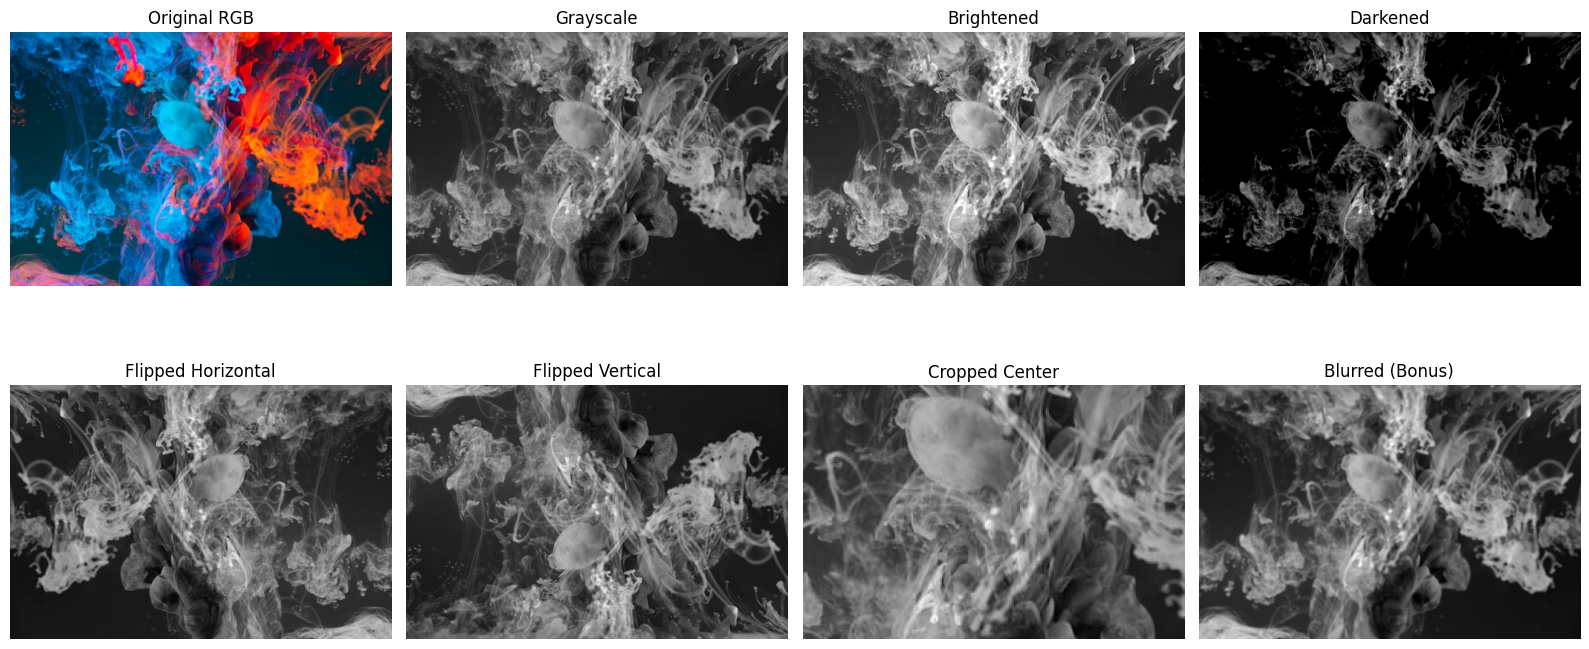

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

axes[0].imshow(img)
axes[0].set_title("Original RGB")

axes[1].imshow(gray_img, cmap="gray")
axes[1].set_title("Grayscale")

axes[2].imshow(bright_img, cmap="gray")
axes[2].set_title("Brightened")

axes[3].imshow(dark_img, cmap="gray")
axes[3].set_title("Darkened")

axes[4].imshow(flip_lr, cmap="gray")
axes[4].set_title("Flipped Horizontal")

axes[5].imshow(flip_ud, cmap="gray")
axes[5].set_title("Flipped Vertical")

axes[6].imshow(crop_img, cmap="gray")
axes[6].set_title("Cropped Center")

axes[7].imshow(blur_img, cmap="gray")
axes[7].set_title("Blurred (Bonus)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()